In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

Generate Data

In [3]:
X_train = np.linspace(-1, 1, 20)

In [4]:
y_train = np.array([-0.6561 , -0.3099 , -0.59035, -0.50855, -0.285  , 
                    -0.2443 , -0.02445,  0.00135, -0.2006 ,  0.07475, 
                    -0.1422 ,  0.06515,  0.15265,  0.3521 ,  0.28415,  
                    0.5524 ,  0.23115,  0.20835, 0.4211,  0.60485])

In [5]:
X_test = np.linspace(-1, 1, 20)

In [6]:
y_test = np.array([-0.69415, -0.451  , -0.43005, -0.4484 , -0.1475 ,
                   -0.5019 , -0.28055,  0.24595, -0.21425, -0.0286 ,  
                   0.23415,  0.46575, 0.07955,  0.1973 ,  0.0719 ,
                   0.3639 ,  0.5536 ,  0.3365 , 0.50705,  0.33435])

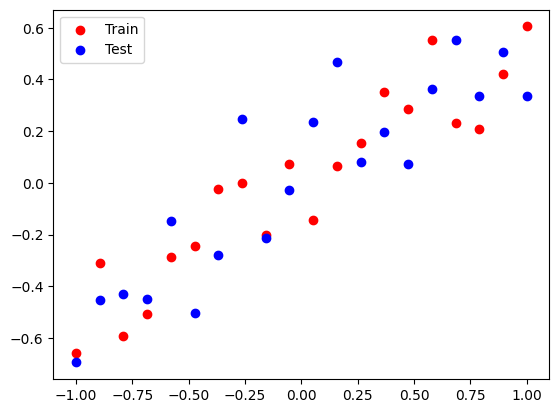

In [7]:
plt.scatter(X_train, y_train, c='red', label='Train')
plt.scatter(X_test, y_test, c='blue', label='Test')
plt.legend()
plt.show()

# Regression Model

In [8]:
model_1 = Sequential()

model_1.add(Dense(128, input_dim=1, activation="relu"))
model_1.add(Dense(128, activation="relu"))
model_1.add(Dense(1, activation="linear"))

c:\Users\ABDULLAH AL MASUM\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
adam = Adam(learning_rate=0.01)
model_1.compile(loss='mse', metrics=['mse'], optimizer=adam)

In [10]:
history = model_1.fit(X_train, y_train, epochs=500, validation_data=(X_test, y_test), verbose=False)

In [11]:
_, train_mse = model_1.evaluate(X_train, y_train, verbose=False)
_, test_mse = model_1.evaluate(X_test, y_test)
print('Train : {}, Test : {}'.format(train_mse, test_mse))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0440 - mse: 0.0440
Train : 0.0026421453803777695, Test : 0.043958406895399094


In [12]:
y_pred_1 = model_1.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


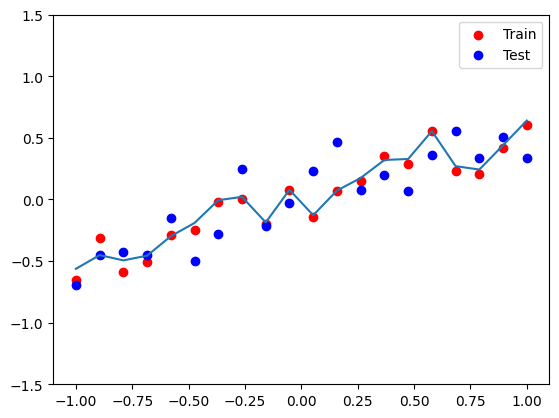

In [13]:
plt.figure()
plt.scatter(X_train, y_train, c='red', label='Train')
plt.scatter(X_test, y_test, c='blue', label='Test')
plt.plot(X_test, y_pred_1)
plt.legend()
plt.ylim((-1.5, 1.5))
plt.show()


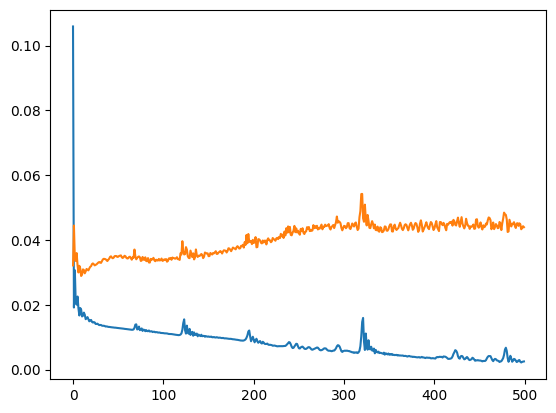

In [14]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

# Dropout Model

In [15]:
model_2 = Sequential()

model_2.add(Dense(128, input_dim=1, activation='relu'))
# model_2.add(Dropout(0.5))
model_2.add(Dense(128, activation='relu'))
model_2.add(Dropout(0.5))
model_2.add(Dense(1, activation='linear'))

In [16]:
adam = Adam(learning_rate=0.01)
model_2.compile(loss='mse', metrics=['mse'], optimizer=adam)

In [17]:
drop_out_history = model_2.fit(X_train, y_train,epochs=500, validation_data=(X_test, y_test), verbose=False)

In [18]:
y_pred_2 = model_2.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


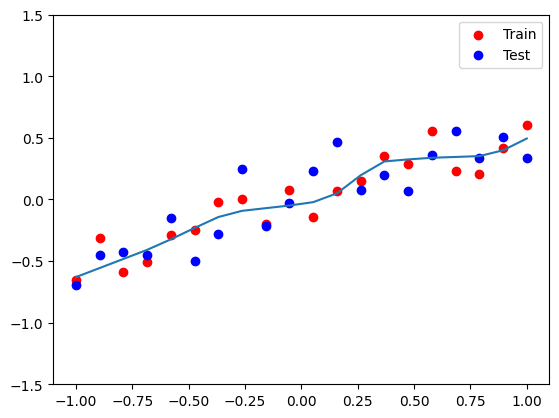

In [19]:
plt.figure()
plt.scatter(X_train, y_train, c='red', label='Train')
plt.scatter(X_test, y_test, c='blue', label='Test')
plt.plot(X_test, y_pred_2)
plt.legend()
plt.ylim((-1.5, 1.5))
plt.show()

In [20]:
_, train_mse = model_2.evaluate(X_train, y_train, verbose=False)
_, test_mse = model_2.evaluate(X_test, y_test)
print('Train : {}, Test : {}'.format(train_mse, test_mse))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0344 - mse: 0.0344
Train : 0.01259118877351284, Test : 0.03443283587694168


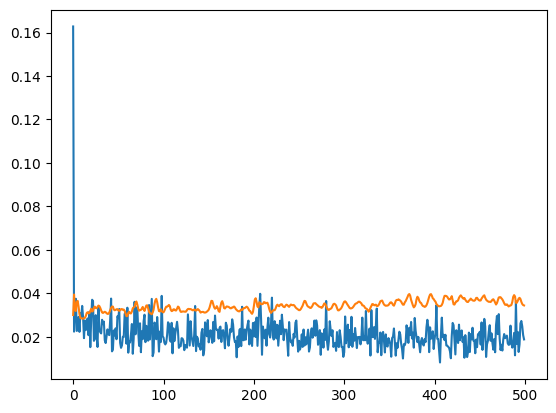

In [21]:
plt.plot(drop_out_history.history['loss'])
plt.plot(drop_out_history.history['val_loss'])